Imports


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
%matplotlib inline

Bresenham algorithm



In [26]:
def bresenham(x0,y0,x1,y1):
    points = []
    
    delta_x = abs(x1 - x0)
    delta_y = abs(y1 - y0)
    
    direction_x = 1 if x0 < x1 else -1
    direction_y = 1 if y0 < y1 else -1
    
    error = delta_x - delta_y

    while True:
        points.append((x0, y0))
        
        if x0 == x1 and y0 == y1:
            break
            
        error_x2 = 2 * error
        
        #horizontal move
        if error_x2 > -delta_y:
            error -= delta_y
            x0 += direction_x
            
        #vertical mvoe
        if error_x2 < delta_x:
            error += delta_x
            y0 += direction_y
            
    return points

Making sinogram


In [27]:
def generate_sinogram(bitmap, angles, n_detectors, l_degrees):
    H, W = bitmap.shape
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    R = min(W, H) / 2.0
    phi = np.radians(l_degrees)

    sinogram = np.zeros((len(angles), n_detectors))

    for i, alpha_deg in enumerate(angles):
        alpha = np.radians(alpha_deg)

        for j in range(n_detectors):
            if n_detectors > 1:
                offset_angle = -phi / 2 + j * phi / (n_detectors - 1)
            else:
                offset_angle = 0.0

            # Emiter: alpha + offset (jedna strona okręgu)
            ex = cx + R * np.cos(alpha + offset_angle)
            ey = cy + R * np.sin(alpha + offset_angle)

            # Detektor: NAPRZECIWKO – alpha + pi - offset_angle
            # żeby promień był równoległy do głównej osi (alpha -> alpha+pi)
            dx = cx + R * np.cos(alpha + np.pi - offset_angle)
            dy = cy + R * np.sin(alpha + np.pi - offset_angle)

            pixels = bresenham(int(round(ex)), int(round(ey)),
                               int(round(dx)), int(round(dy)))

            sinogram[i, j] = sum(
                bitmap[py, px]
                for px, py in pixels
                if 0 <= px < W and 0 <= py < H
            )

    if sinogram.max() > 0:
        sinogram /= sinogram.max()
    return sinogram

def filter_sinogram(sinogram):
    #ram lak filter
    
    #detectors number (sinogram width)
    n = sinogram.shape[1]
    freq = np.fft.fftfreq(n) #frequency list
    ramp = np.abs(freq) 
    
    filtered = np.zeros_like(sinogram)
    for i in range(sinogram.shape[0]):
        proj_f = np.fft.fft(sinogram[i])
        f_filtered = proj_f * ramp
        filtered[i] = np.real(np.fft.ifft(f_filtered))

    return filtered

Reconstruction



In [ ]:
def backproject(sinogram, angles, n_detectors, l_degrees, H, W):
    reconstruction = np.zeros((H, W))
    cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
    R = min(W, H) / 2.0
    phi = np.radians(l_degrees)

    x_grid = np.arange(W, dtype=np.float64)
    y_grid = np.arange(H, dtype=np.float64)
    X, Y = np.meshgrid(x_grid, y_grid)
    det_indices = np.arange(n_detectors, dtype=np.float64)

    # Zasięg detektorów wzdłuż osi prostopadłej
    # j-ty detektor ma środek w s_j = R * sin(offset_angle_j)
    # ale dla małych kątów sin(x) ≈ x, więc liniowe mapowanie jest OK
    # Dokładnie: s_j = R * sin(-phi/2 + j*phi/(n-1))
    # Prekomputuj pozycje detektorów na osi s
    if n_detectors > 1:
        det_offsets = np.array([-phi/2 + j * phi / (n_detectors - 1) 
                                 for j in range(n_detectors)])
    else:
        det_offsets = np.array([0.0])
    det_s = R * np.sin(det_offsets)  # rzeczywiste pozycje na osi prostopadłej

    for i, alpha_deg in enumerate(angles):
        alpha = np.radians(alpha_deg)

        perp_x = -np.sin(alpha)
        perp_y =  np.cos(alpha)

        # Rzut każdego piksela na oś prostopadłą
        s = (X - cx) * perp_x + (Y - cy) * perp_y

        # Interpoluj względem rzeczywistych pozycji detektorów (det_s)
        proj = np.interp(s.ravel(), det_s, sinogram[i], left=0.0, right=0.0)
        reconstruction += proj.reshape(H, W)

    reconstruction = np.maximum(reconstruction, 0)
    mx = reconstruction.max()
    if mx > 0:
        reconstruction /= mx
    return reconstruction

MSE

In [29]:
def mse(img_ref, img_out):
    ref = np.clip(img_ref, 0, 1)
    out = np.clip(img_out, 0, 1)
    #resizing because padding added earlier
    if ref.shape != out.shape:
        out_pil = Image.fromarray((out * 255).astype(np.uint8))
        out = np.array(out_pil.resize((ref.shape[1], ref.shape[0]),
                           Image.BILINEAR)) / 255.0
    return float(np.mean((ref - out) ** 2))

Image operations

In [30]:
def get_image_list(folder='img'):
    supported_extensions = ('.jpg')
    if not os.path.exists(folder):
        return []
    return [f for f in os.listdir(folder) if f.lower().endswith(supported_extensions)]

image_options = get_image_list()

def prepare_bitmap(img_path):
    img = Image.open(img_path).convert("L")
    arr = np.array(img) / 255.0
    h, w = arr.shape
    
    new_size = int(np.ceil(np.sqrt(h**2 + w**2) * 1.1))
    
    padded = np.zeros((new_size, new_size))
    
    y_off = (new_size - h) // 2
    x_off = (new_size - w) // 2
    padded[y_off:y_off+h, x_off:x_off+w] = arr
    
    return padded

bitmap = prepare_bitmap("img/Shepp_logan.jpg")
H, W = bitmap.shape


Settings/Sliders for visualization of starting image, sinogram and reconstructed image}


In [31]:
style  = {'description_width': '140px'}
layout = widgets.Layout(width='500px')

dropdown_img = widgets.Dropdown(
    options=image_options,
    value=image_options[0] if image_options else None,
    description='Select Image:',
    style=style, layout=layout
)

def on_image_change(change):
    global bitmap, H, W
    if change['new']:
        path = os.path.join('img', change['new'])
        bitmap = prepare_bitmap(path)
        H, W = bitmap.shape
        state.update(sinogram=None, angles=None)
        status_lbl.value = f'Loaded: {change["new"]}. Ready to generate.'
        with out:
            clear_output()
            fig, ax = plt.subplots(figsize=(4,4))
            ax.imshow(bitmap, cmap='gray')
            ax.set_title("New image loaded")
            ax.axis('off')
            plt.show()

dropdown_img.observe(on_image_change, names='value')

slider_a_delta = widgets.FloatSlider(value=1.0, min=0.5, max=5.0, step=0.5,
    description='delta_a [st]', continuous_update=False, style=style, layout=layout)
slider_n_detectors = widgets.IntSlider(value=180, min=90, max=360, step=10,
    description='n detectors', continuous_update=False, style=style, layout=layout)
slider_l_degrees = widgets.IntSlider(value=180, min=10, max=270, step=5,
    description='l [st]', continuous_update=False, style=style, layout=layout)
slider_level  = widgets.IntSlider(value=1, min=1, max=180, step=1,
    description='progress:', continuous_update=False,
    style={'description_width': '120px'}, layout=widgets.Layout(width='500px'),
    disabled=True)

chk_filter  = widgets.Checkbox(value=False, description='Use filter',
    layout=widgets.Layout(width='200px'))



btn_gen = widgets.Button(description='Generate', button_style='primary',
    layout=widgets.Layout(width='120px'))
btn_full = widgets.Button(description='Full image', button_style='success',
    layout=widgets.Layout(width='130px'), disabled=True)
progress = widgets.IntProgress(value=0, min=0, max=100, description='Progress:',
    bar_style='info', layout=widgets.Layout(width='500px'))
status_lbl = widgets.Label(value='Choose parameters and generate image')

out = widgets.Output()

state = dict(sinogram=None, angles = None, n_det=None, l=None)

def rysuj(sino, rec, n, total):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    
    axes[0].imshow(bitmap, cmap='gray', vmin=0, vmax=1)
    
    if n > 0:
        alpha_deg = state['angles'][n-1]
        l_deg = state['l']
        cx, cy = (W - 1) / 2.0, (H - 1) / 2.0
        R_vis = min(W, H) / 2.0
        phi = np.radians(l_deg)
        alpha = np.radians(alpha_deg)

        # Okrąg skanera
        theta = np.linspace(0, 2 * np.pi, 300)
        axes[0].plot(cx + R_vis * np.cos(theta),
                     cy + R_vis * np.sin(theta),
                     'gray', linewidth=0.8, alpha=0.4)

        if state['n_det'] > 1:
            offsets = np.linspace(-phi/2, phi/2, state['n_det'])
        else:
            offsets = np.array([0.0])

        ex = cx + R_vis * np.cos(alpha + offsets)
        ey = cy + R_vis * np.sin(alpha + offsets)
        dx = cx + R_vis * np.cos(alpha + np.pi - offsets)
        dy = cy + R_vis * np.sin(alpha + np.pi - offsets)

        # Promienie
        step = max(1, state['n_det'] // 12)
        for j in range(0, state['n_det'], step):
            axes[0].plot([ex[j], dx[j]], [ey[j], dy[j]],
                         'y-', alpha=0.25, linewidth=0.7)

        # Łuk emiterów
        arc_e = np.linspace(alpha - phi/2, alpha + phi/2, 100)
        axes[0].plot(cx + R_vis * np.cos(arc_e),
                     cy + R_vis * np.sin(arc_e),
                     'b-', linewidth=3, label='Emitters')

        # Łuk detektorów
        arc_d = np.linspace(alpha + np.pi - phi/2, alpha + np.pi + phi/2, 100)
        axes[0].plot(cx + R_vis * np.cos(arc_d),
                     cy + R_vis * np.sin(arc_d),
                     'r-', linewidth=3, label='Detectors')

        # Punkt środkowy detektorów
        mid_angle = alpha + np.pi
        mid_x = cx + R_vis * np.cos(mid_angle)
        mid_y = cy + R_vis * np.sin(mid_angle)
        axes[0].plot(mid_x, mid_y, 'r^', markersize=10, zorder=5)

        # Punkt środkowy emiterów
        mid_e_x = cx + R_vis * np.cos(alpha)
        mid_e_y = cy + R_vis * np.sin(alpha)
        axes[0].plot(mid_e_x, mid_e_y, 'b^', markersize=10, zorder=5)

        axes[0].legend(loc='upper right', fontsize=7)

    axes[0].set_title('input image')
    axes[0].axis('off')

    axes[1].imshow(sino, cmap='gray', aspect='auto')
    axes[1].set_title(f'Sinogram ({n}/{total})')

    axes[2].imshow(rec, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'Reconstruction ({n}/{total})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


def on_gen(b):
    state.update(sinogram=None, angles=None)
    
    # Wyczyść stary output od razu
    with out:
        clear_output(wait=True)

    angles = np.arange(0, 180, float(slider_a_delta.value))
    n_det = int(slider_n_detectors.value)
    l_deg = float(slider_l_degrees.value)
    total = len(angles)

    btn_gen.disabled = True
    slider_level.disabled = True
    btn_full.disabled = True
    progress.max = total
    progress.value = 0
    status_lbl.value = 'Sinogram...'

    sino = generate_sinogram(bitmap, angles, n_det, l_deg)
    if chk_filter.value:
        sino_do_bp = filter_sinogram(sino)
    else:
        sino_do_bp = sino

    progress.value = total // 2
    status_lbl.value = 'Reconstruction...'
    rec = backproject(sino_do_bp, angles, n_det, l_deg, H, W)
    progress.value = total

    state.update(sinogram=sino_do_bp, angles=angles, n_det=n_det, l=l_deg)
    slider_level.max = total
    slider_level.value = total
    slider_level.disabled = False
    btn_full.disabled = False
    btn_gen.disabled = False
    status_lbl.value = f'Ready  {total} angles | {n_det} det | l={l_deg:.0f}st'

    with out:
        clear_output(wait=True)
        rysuj(sino_do_bp, rec, total, total)


def on_prog(change):
    if state['sinogram'] is None:
        return
    n = min(change['new'], len(state['angles']))
    sino_n = state['sinogram'][:n]
    rec_n = backproject(sino_n, state['angles'][:n], state['n_det'], state['l'], H, W)
    with out:
        clear_output(wait=True)
        rysuj(sino_n, rec_n, n, len(state['angles']))


def on_full(b):
    if state['angles'] is not None:
        slider_level.value = len(state['angles'])




btn_gen.on_click(on_gen)
slider_level.observe(on_prog, names='value')
btn_full.on_click(on_full)

display(widgets.VBox([
    widgets.HTML('<b>Input Data</b>'),
    dropdown_img,
    widgets.HTML('<b>Parameters</b>'),
    slider_a_delta, slider_n_detectors, slider_l_degrees,
    chk_filter,
    widgets.HBox([btn_gen, widgets.Label('   '), status_lbl]),
    progress,
    widgets.HBox([slider_level, btn_full]),
    out,
]))

analysis


In [32]:
def run_statistical_analysis():
    if state['sinogram'] is None:
        print("generate a sinogram first")
        return

    angles = state['angles']
    n_det = state['n_det']
    l_deg = state['l']
    total_steps = len(angles)
    
    # 1. MSE vs Iterations
    mse_iterations = []
    steps = np.linspace(1, total_steps, 10, dtype=int)
    for n in steps:
        rec = backproject(state['sinogram'][:n], angles[:n], n_det, l_deg, H, W)
        mse_iterations.append(mse(bitmap, rec))

    # 2. MSE vs Detector Count
    det_counts = [90, 180, 270, 360]
    mse_detectors = []
    for d in det_counts:
        sino = generate_sinogram(bitmap, angles, d, l_deg)
        if chk_filter.value: sino = filter_sinogram(sino)
        rec = backproject(sino, angles, d, l_deg, H, W)
        mse_detectors.append(mse(bitmap, rec))

    # 3. Filter Impact
    sino_raw = generate_sinogram(bitmap, angles, n_det, l_deg)
    mse_no_filter = mse(bitmap, backproject(sino_raw, angles, n_det, l_deg, H, W))
    mse_filter = mse(bitmap, backproject(filter_sinogram(sino_raw), angles, n_det, l_deg, H, W))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(steps, mse_iterations, 'o-b')
    axes[0].set_title('MSE vs Number of Angles')
    axes[0].grid(True)

    axes[1].plot(det_counts, mse_detectors, 'o-g')
    axes[1].set_title('MSE vs Detector Count')
    axes[1].grid(True)

    axes[2].bar(['Off', 'On'], [mse_no_filter, mse_filter], color=['orange', 'skyblue'])
    axes[2].set_title('Filter Impact on MSE')
    
    plt.tight_layout()
    plt.show()

btn_analyze = widgets.Button(description='Run Analysis', button_style='info')
out_analyze = widgets.Output()

def on_analyze_clicked(b):
    with out_analyze:
        clear_output(wait=True)
        print('analysis in progress')
        run_statistical_analysis()

btn_analyze.on_click(on_analyze_clicked)
display(btn_analyze, out_analyze)

Button(button_style='info', description='Run Analysis', style=ButtonStyle())

Output()

DICOM


In [33]:
import pydicom
from pydicom.dataset import Dataset, FileDataset, FileMetaDataset
from pydicom.uid import generate_uid, ExplicitVRLittleEndian
import datetime

In [34]:
style_d  = {'description_width': '160px'}
layout_d = widgets.Layout(width='480px')

txt_name    = widgets.Text(value='Jan Kowalski',   description='Firstname and lastname',  style=style_d, layout=layout_d)
txt_birth   = widgets.Text(value='RRRRMMDD',               description='Birth date (RRRRMMDD)', style=style_d, layout=layout_d)
txt_date    = widgets.Text(value=datetime.date.today().strftime('%Y%m%d'),
                               description='Study date (RRRRMMDD)', style=style_d, layout=layout_d)
txt_comment = widgets.Textarea(value='test comment',           description='Comment',         style=style_d,
                               layout=widgets.Layout(width='480px', height='70px'))
txt_outpath = widgets.Text(value='ct_result.dcm',      description='filename .dcm',  style=style_d, layout=layout_d)

btn_save = widgets.Button(description='Zapisz DICOM', button_style='warning',
                          layout=widgets.Layout(width='160px'))
btn_load = widgets.Button(description='Wczytaj DICOM', button_style='info',
                          layout=widgets.Layout(width='160px'))
txt_loadpath = widgets.Text(value='ct_result.dcm', description='file to load',
                            style=style_d, layout=layout_d)

dicom_status = widgets.Label(value='')
out_dicom    = widgets.Output()

display(widgets.VBox([
    widgets.HTML('<b>Dane pacjenta i badania</b>'),
    txt_name, txt_birth, txt_date, txt_comment,
    widgets.HTML('<b>Zapis</b>'),
    txt_outpath, btn_save,
    widgets.HTML('<b>Odczyt</b>'),
    txt_loadpath, btn_load,
    dicom_status,
    out_dicom,
]))

In [35]:
def arr_to_uint16(arr):
    a = np.clip(arr, 0, 1)
    return (a * 4095).astype(np.uint16)


def build_dicom(pixel_uint16, patient_name, birth_date, study_date, comment):
    rows, cols = pixel_uint16.shape
    sop_uid = generate_uid()

    file_meta = FileMetaDataset()
    file_meta.FileMetaInformationGroupLength = 0 
    file_meta.FileMetaInformationVersion = b'\x00\x01'
    file_meta.MediaStorageSOPClassUID = '1.2.840.10008.5.1.4.1.1.2'
    file_meta.MediaStorageSOPInstanceUID = sop_uid
    file_meta.TransferSyntaxUID = ExplicitVRLittleEndian
    file_meta.ImplementationClassUID = '1.2.3.4.5'

    ds = FileDataset(None, {}, file_meta=file_meta, preamble=b'\x00' * 128)
    
    ds.PatientName = patient_name
    ds.PatientID = "123456"
    ds.PatientBirthDate = birth_date
    ds.PatientSex = "O"
    ds.StudyDate = study_date
    ds.SeriesDate = study_date
    ds.AcquisitionDate = study_date
    ds.ContentDate = study_date
    
    ds.Modality = "CT"
    ds.SeriesInstanceUID = generate_uid()
    ds.StudyInstanceUID = generate_uid()
    ds.SOPClassUID = '1.2.840.10008.5.1.4.1.1.2'
    ds.SOPInstanceUID = sop_uid
    ds.InstanceNumber = "1"

    ds.SamplesPerPixel = 1
    ds.PhotometricInterpretation = 'MONOCHROME2'
    ds.Rows = rows
    ds.Columns = cols
    ds.BitsAllocated = 16
    ds.BitsStored = 16
    ds.HighBit = 15
    ds.PixelRepresentation = 0 
    
    ds.RescaleIntercept = "0"
    ds.RescaleSlope = "1"

    ds.PixelData = pixel_uint16.tobytes()

    return ds


def on_save(b):
    # check if image already reconstructed
    if state.get('sinogram') is None:
        dicom_status.value = 'first you must generate reconstruction'
        return

    rec = backproject(
        state['sinogram'], state['angles'],
        state['n_det'], state['l'], H, W
    )

    pixel16 = arr_to_uint16(rec)
    ds = build_dicom(
        pixel16,
        patient_name = txt_name.value,
        birth_date   = txt_birth.value,
        study_date   = txt_date.value,
        comment      = txt_comment.value,
    )

    path = txt_outpath.value or 'ct_result.dcm'
    pydicom.dcmwrite(path, ds)
    dicom_status.value = f'saved'


def on_load(b):
    path = txt_loadpath.value
    if not os.path.exists(path):
        dicom_status.value = f'File not found "{path}"'
        return

    ds = pydicom.dcmread(path)
    arr = ds.pixel_array.astype(np.float64)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

    with out_dicom:
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(arr, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'Wczytano: {os.path.basename(path)}')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

        # pokaz metadane
        def tag(name, default='—'):
            return str(getattr(ds, name, default))

        print(f'  Patient:        {tag("PatientName")}')
        print(f'  Birth date: {tag("PatientBirthDate")}')
        print(f'  Study date:   {tag("StudyDate")}')
        print(f'  Comment:      {tag("ImageComments")}')

    dicom_status.value = f'Showing: {path}'


btn_save.on_click(on_save)
btn_load.on_click(on_load)

Eksperyment

KeyboardInterrupt: 

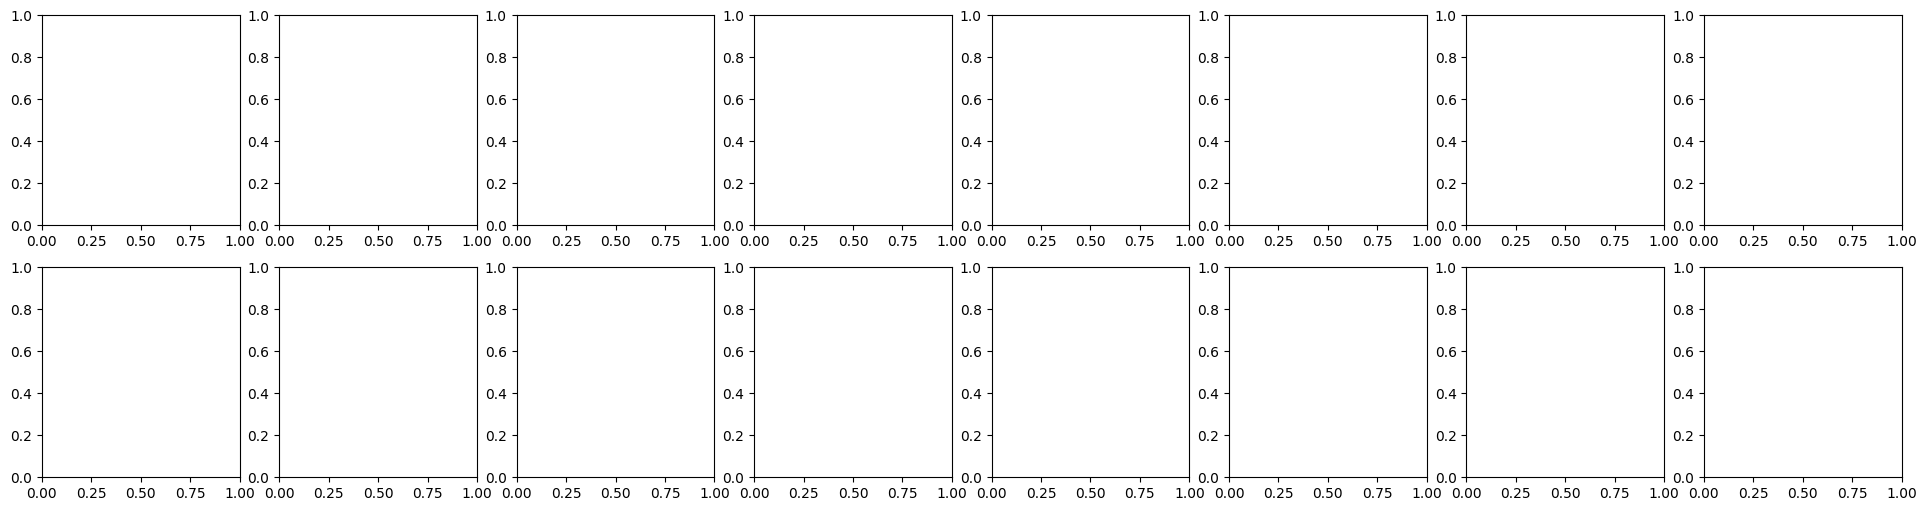

In [36]:
default_det = 180
default_scans = 180
default_l = 180
angles_default = np.arange(0, 180, 180 / default_scans)

# detectors number
det_values = list(range(90, 721, 90))
rmse_det = []
angles_default = np.arange(0, 180, 180 / default_scans)

n_cols = len(det_values)
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 6))

for i, d in enumerate(det_values):
    sino = generate_sinogram(bitmap, angles_default, d, default_l)
    rec  = backproject(sino, angles_default, d, default_l, H, W)
    r    = np.sqrt(mse(bitmap, rec))
    rmse_det.append(r)
    
    axes[0, i].imshow(rec, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'd={d}', fontsize=9)
    axes[0, i].axis('off')
    
    axes[1, i].text(0.5, 0.5, f'RMSE\n{r:.4f}',
                    ha='center', va='center', fontsize=10, transform=axes[1, i].transAxes)
    axes[1, i].axis('off')

plt.suptitle('Wpływ liczby detektorów na jakość rekonstrukcji', fontsize=12)
plt.tight_layout()
plt.savefig('detektory_obrazy.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(det_values, rmse_det, 'o-b')
plt.title('RMSE vs liczba detektorów')
plt.xlabel('Liczba detektorów')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
plt.savefig('rmse_detektory.png', dpi=150)
plt.show()


# scans
scan_values = list(range(90, 721, 90))
rmse_scans = []

fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 6))

for i, s in enumerate(scan_values):
    angles = np.arange(0, 180, 180 / s)
    sino = generate_sinogram(bitmap, angles, default_det, default_l)
    rec  = backproject(sino, angles, default_det, default_l, H, W)
    r    = np.sqrt(mse(bitmap, rec))
    rmse_scans.append(r)
    
    axes[0, i].imshow(rec, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f's={s}', fontsize=9)
    axes[0, i].axis('off')
    
    axes[1, i].text(0.5, 0.5, f'RMSE\n{r:.4f}',
                    ha='center', va='center', fontsize=10, transform=axes[1, i].transAxes)
    axes[1, i].axis('off')

plt.suptitle('Wpływ liczby skanów na jakość rekonstrukcji', fontsize=12)
plt.tight_layout()
plt.savefig('skany_obrazy.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(scan_values, rmse_scans, 'o-g')
plt.title('RMSE vs liczba skanów')
plt.xlabel('Liczba skanów')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
plt.savefig('rmse_skany.png', dpi=150)
plt.show()


# l_degrees
l_values = list(range(45, 271, 45))
rmse_l = []

n_cols_l = len(l_values)
fig, axes = plt.subplots(2, n_cols_l, figsize=(n_cols_l * 3, 6))

for i, l in enumerate(l_values):
    sino = generate_sinogram(bitmap, angles_default, default_det, l)
    rec  = backproject(sino, angles_default, default_det, l, H, W)
    r    = np.sqrt(mse(bitmap, rec))
    rmse_l.append(r)
    
    axes[0, i].imshow(rec, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'l={l}°', fontsize=9)
    axes[0, i].axis('off')
    
    axes[1, i].text(0.5, 0.5, f'RMSE\n{r:.4f}',
                    ha='center', va='center', fontsize=10, transform=axes[1, i].transAxes)
    axes[1, i].axis('off')

plt.suptitle('Wpływ rozpiętości wachlarza na jakość rekonstrukcji', fontsize=12)
plt.tight_layout()
plt.savefig('wachlarz_obrazy.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(l_values, rmse_l, 'o-r')
plt.title('RMSE vs rozpiętość wachlarza [°]')
plt.xlabel('Rozpiętość wachlarza [°]')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
plt.savefig('rmse_wachlarz.png', dpi=150)
plt.show()

img/CT_ScoutView.jpg
  RMSE bez filtrowania: 0.21738
  RMSE z filtrowaniem:  0.03477


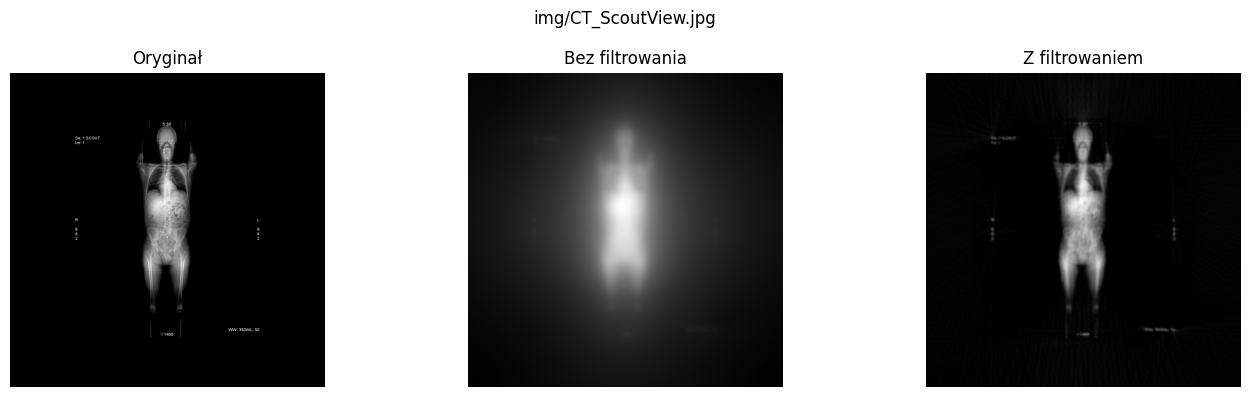

img/Shepp_logan.jpg
  RMSE bez filtrowania: 0.44089
  RMSE z filtrowaniem:  0.05553


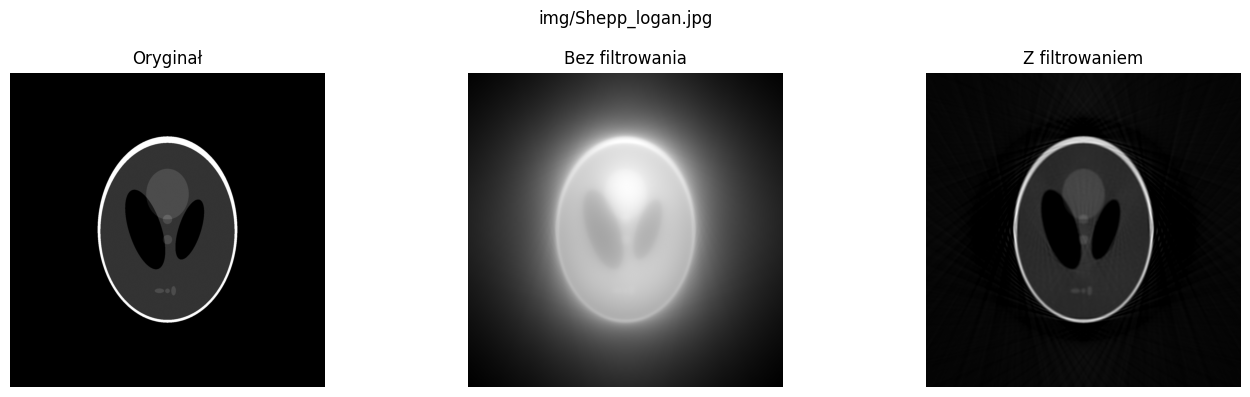

In [ ]:
# --- 4. Porównanie filtrowania dla 2 obrazów ---
params = dict(n_det=360, l=270)
angles_360 = np.arange(0, 180, 180 / 360)

for img_name in ["img/CT_ScoutView.jpg", "img/Shepp_logan.jpg"]:
    bmp = prepare_bitmap(img_name)
    h, w = bmp.shape

    sino = generate_sinogram(bmp, angles_360, params['n_det'], params['l'])

    rec_nof = backproject(sino, angles_360, params['n_det'], params['l'], h, w)
    rec_f   = backproject(filter_sinogram(sino), angles_360,
                          params['n_det'], params['l'], h, w)

    print(f"{img_name}")
    print(f"  RMSE bez filtrowania: {np.sqrt(mse(bmp, rec_nof)):.5f}")
    print(f"  RMSE z filtrowaniem:  {np.sqrt(mse(bmp, rec_f)):.5f}")

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(bmp,     cmap='gray'); axes[0].set_title('Oryginał');        axes[0].axis('off')
    axes[1].imshow(rec_nof, cmap='gray'); axes[1].set_title('Bez filtrowania'); axes[1].axis('off')
    axes[2].imshow(rec_f,   cmap='gray'); axes[2].set_title('Z filtrowaniem');  axes[2].axis('off')
    plt.suptitle(img_name)
    plt.tight_layout()
    plt.show()